# Combine networks generated from Mesoderm, endoderm, & ectoderm

In [69]:
suppressMessages(library(igraph))
# suppressMessages(library(intergraph))
suppressMessages(library(ggraph))
suppressMessages(library(tibble))
suppressMessages(library(tidygraph))
suppressMessages(library(data.table))
suppressMessages(library(ggpubr))

In [117]:
io = list()
io$basedir = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/rna_atac/gene_regulatory_networks/scenicplus/'

theme_graph <- function() {
  theme_classic() +
    theme(
      axis.line = element_blank(), 
      axis.text = element_blank(),
      axis.ticks = element_blank(), 
      axis.title = element_blank(),
      legend.position = "none"
    )
}

celltype.colors = c(
  "Epiblast" = "#635547",
  "Primitive_Streak" = "#DABE99",
  "Caudal_epiblast" = "#9e6762",
  "PGC" = "#FACB12",
  "Anterior_Primitive_Streak" = "#c19f70",
  "Notochord" = "#0F4A9C",
  "Def._endoderm" = "#F397C0",
  "Gut" = "#EF5A9D",
  "Nascent_mesoderm" = "#C594BF",
  "Mixed_mesoderm" = "#DFCDE4",
  "Intermediate_mesoderm" = "#139992",
  "Caudal_Mesoderm" = "#3F84AA",
  "Paraxial_mesoderm" = "#8DB5CE",
  "Somitic_mesoderm" = "#005579",
  "Pharyngeal_mesoderm" = "#C9EBFB",
  "Cardiomyocytes" = "#B51D8D",
  "Allantois" = "#532C8A",
  "ExE_mesoderm" = "#8870ad",
  "Mesenchyme" = "#cc7818",
  "Haematoendothelial_progenitors" = "#FBBE92",
  "Endothelium" = "#ff891c",
  "Blood_progenitors" = "#c9a997",
  "Blood_progenitors_1" = "#f9decf",
  "Blood_progenitors_2" = "#c9a997",
  "Erythroid" = "#EF4E22",
  "Erythroid1" = "#C72228",
  "Erythroid2" = "#f79083",
  "Erythroid3" = "#EF4E22",
  "NMP" = "#8EC792",
  "Neurectoderm" = "#65A83E",
  "Rostral_neurectoderm" = "#65A83E",
  "Caudal_neurectoderm" = "#354E23",
  "Neural_crest" = "#C3C388",
  "Forebrain_Midbrain_Hindbrain" = "#647a4f",
  "Spinal_cord" = "#CDE088",
  "Surface_ectoderm" = "#f7f79e",
  "Visceral_endoderm" = "#F6BFCB",
  "ExE_endoderm" = "#7F6874",
  "ExE_ectoderm" = "#989898",
  "Parietal_endoderm" = "#1A1A1A"
)

In [165]:
marker_TFs_all.dt <- fread('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/pijuansala2019_gastrulation10x/results/differential/celltypes/TFs/TF_markers/marker_TFs_upregulated_all.txt.gz')
celltype_marker = marker_TFs_all.dt %>% .[score>0.75] %>% .[order(-score)] %>% unique(by='gene') %>% .[,c('celltype', 'gene')] %>% setnames('gene', 'TF') %>% setkey('TF')

In [166]:
all_TFs = fread("/rds/project/rds-SDzz0CATGms/users/bt392/software/github/scenicplus/resources/allTFs_mm.txt", header=F)$V1

In [21]:
mesoderm = fread(file.path(io$basedir, 'mesoderm/scenicplus/eRegulon_metadata_filtered.csv'))[,origin:='mesoderm']
endoderm = fread(file.path(io$basedir, 'endoderm/scenicplus/eRegulon_metadata_filtered.csv'))[,origin:='endoderm']
ectoderm = fread(file.path(io$basedir, 'ectoderm/scenicplus/eRegulon_metadata_filtered.csv'))[,origin:='ectoderm']

In [ ]:
full_GRN = rbind(mesoderm, endoderm, ectoderm) %>% 
    .[order(-TF2G_importance)] %>% 
    unique(by=c('TF', 'Region', 'Gene')) %>% 
    .[TF %in% all_TFs & Gene %in% all_TFs]

options(repr.plot.width=20, repr.plot.height=8)
ggarrange(
    ggplot(full_GRN, aes(R2G_importance)) + geom_histogram() + theme_classic(),
    ggplot(full_GRN, aes(R2G_rho)) + geom_histogram() + theme_classic(),
    ggplot(full_GRN, aes(R2G_importance_x_rho)) + geom_histogram() + theme_classic(),
    ggplot(full_GRN, aes(TF2G_importance)) + geom_histogram() + theme_classic(),
    ggplot(full_GRN, aes(TF2G_rho)) + geom_histogram() + theme_classic(),
    ggplot(full_GRN, aes(TF2G_importance_x_rho)) + geom_histogram() + theme_classic(),
    ncol=3
)

In [194]:
full_GRN = rbind(mesoderm, endoderm, ectoderm) %>% 
    .[order(-TF2G_importance)] %>% 
    unique(by=c('TF', 'Region', 'Gene')) %>% 
    .[TF %in% all_TFs & Gene %in% all_TFs] %>%
    .[R2G_importance> 0.1 & TF2G_importance>5] %>%
    .[,c('TF', 'Gene', 'TF2G_importance', 'TF2G_rho', 'TF2G_importance_x_rho', 'TF2G_regulation')] %>% unique(by=c('TF', 'Gene')) %>%
    .[,sign:=ifelse(TF2G_regulation==-1, 'Negative', 'Positive')]

In [195]:
TF_pass = full_GRN %>% unique(by=c('TF', 'Gene')) %>% .[,N:=.N, by='TF'] %>% .[N>5] %>% .$TF %>% unique()

In [196]:
full_GRN = full_GRN[TF %in% TF_pass & Gene %in% TF_pass]

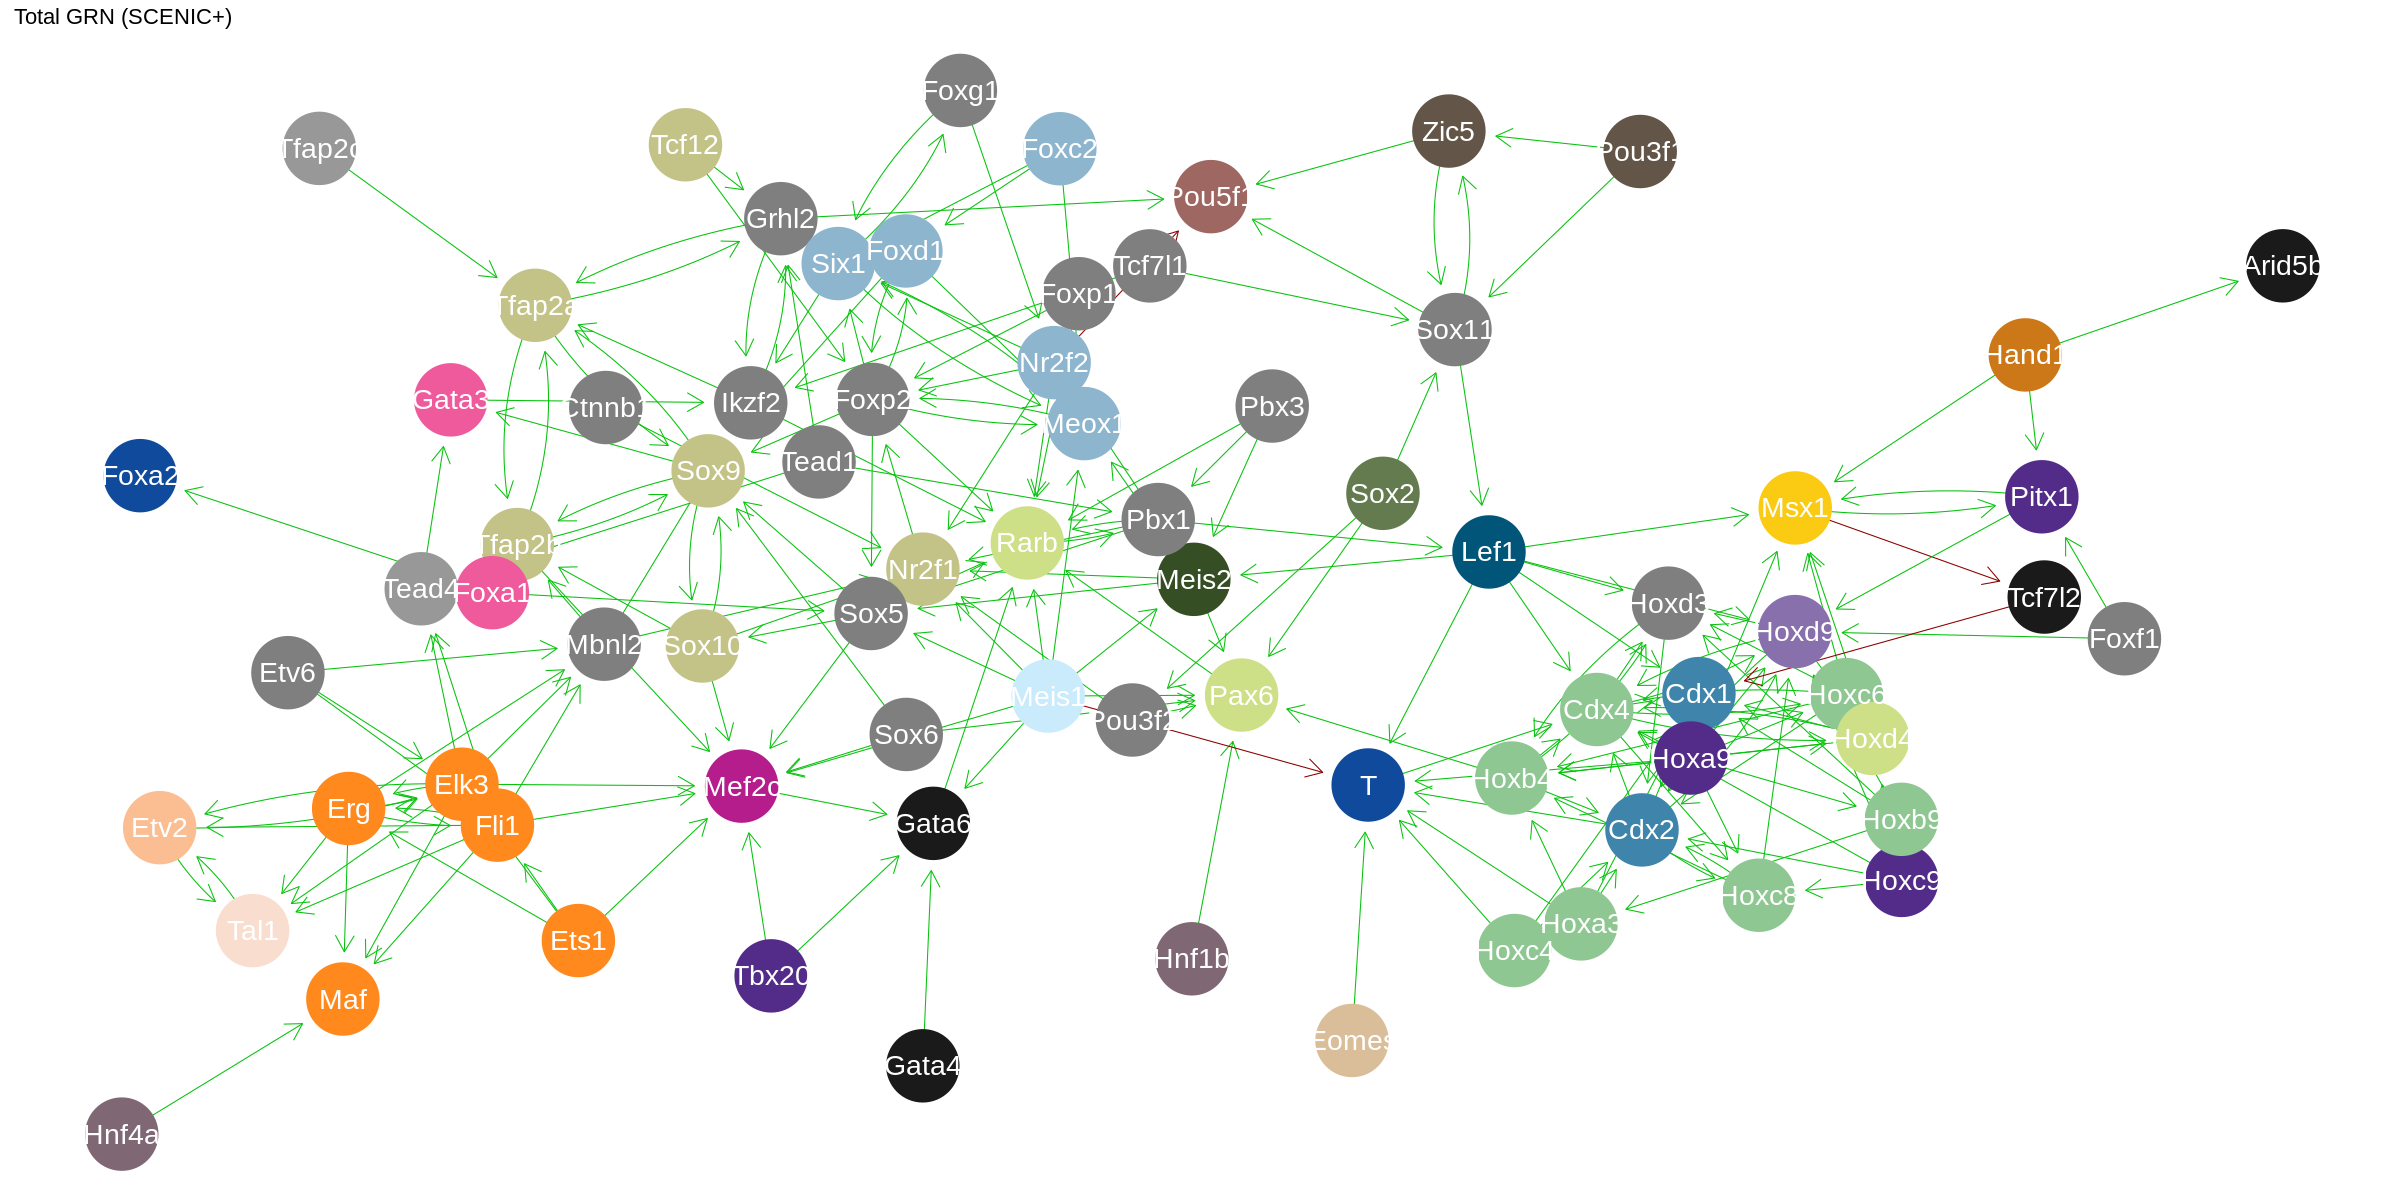

In [197]:
options(repr.plot.width=20, repr.plot.height=10)
igraph.tbl = tbl_graph(edges = full_GRN)
igraph.tbl = igraph.tbl %>% activate(nodes) %>%  mutate(celltype=celltype_marker[names(V(igraph.tbl)),celltype])
ggraph(igraph.tbl, 'stress') +
    # Edges
    geom_edge_fan(aes(edge_color=sign), edge_width=0.3, arrow=arrow(length=unit(4,'mm')), end_cap=circle(10,'mm'), show.legend = T) + 
    scale_edge_colour_manual(values=c("Positive"="#08c20e", "Negative"="darkred")) +
    geom_node_point(aes(col=celltype), size=20) + 
    scale_color_manual(values=celltype.colors) +
    geom_node_text(aes(label=name), size=6, col='white') + 
    theme_graph() + 
    ggtitle('Total GRN (SCENIC+)') + theme(legend.position='none')

In [183]:
filt = mesoderm %>%
    .[order(-TF2G_importance)] %>% 
    .[TF %in% all_TFs & Gene %in% all_TFs] %>%
    .[R2G_importance> 0.05 & TF2G_importance>10] %>%
    .[,c('TF', 'Gene', 'TF2G_importance', 'TF2G_rho', 'TF2G_importance_x_rho', 'TF2G_regulation')] %>% unique(by=c('TF', 'Gene')) %>%
    .[,sign:=ifelse(TF2G_regulation==-1, 'Negative', 'Positive')]

TF_pass = filt %>% unique(by=c('TF', 'Gene')) %>% .[,N:=.N, by='TF'] %>% .[N>3] %>% .$TF %>% unique()
filt = filt[TF %in% TF_pass & Gene %in% TF_pass]


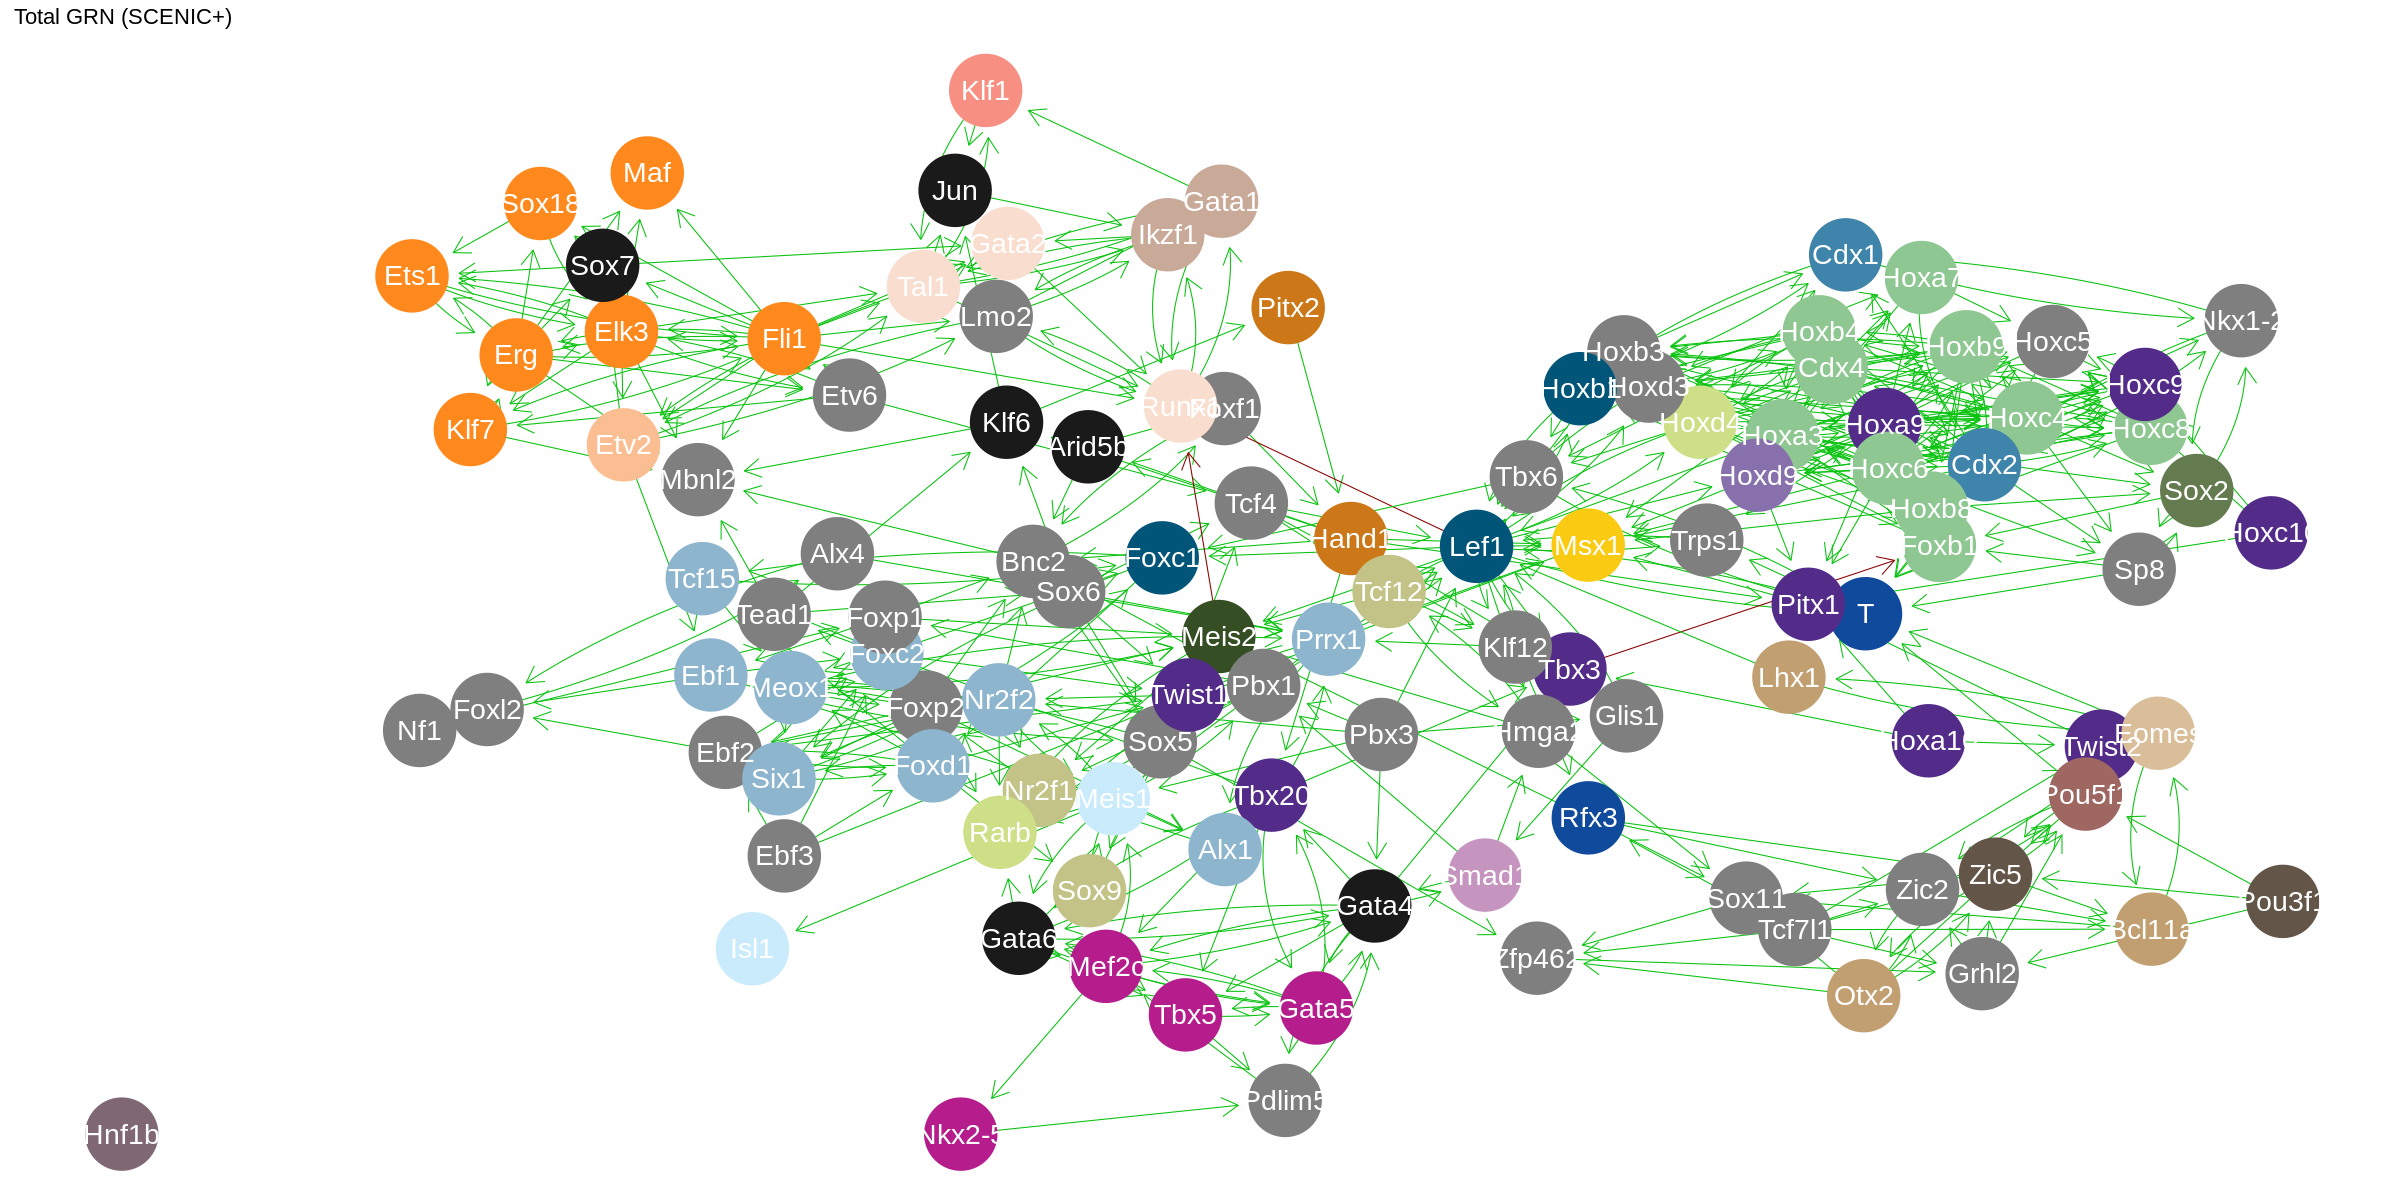

In [185]:
options(repr.plot.width=20, repr.plot.height=10)
igraph.tbl = tbl_graph(edges = filt)
igraph.tbl = igraph.tbl %>% activate(nodes) %>%  mutate(celltype=celltype_marker[names(V(igraph.tbl)),celltype])
ggraph(igraph.tbl, 'stress') +
    # Edges
    geom_edge_fan(aes(edge_color=sign), edge_width=0.3, arrow=arrow(length=unit(4,'mm')), end_cap=circle(10,'mm'), show.legend = T) + 
    scale_edge_colour_manual(values=c("Positive"="#08c20e", "Negative"="darkred")) +
    geom_node_point(aes(col=celltype), size=20) + 
      scale_color_manual(values=c(celltype.colors, 'NA'='#000000')) +  
    geom_node_text(aes(label=name), size=6, col='white') + 
    theme_graph() + 
    ggtitle('Total GRN (SCENIC+)') + theme(legend.position='none')

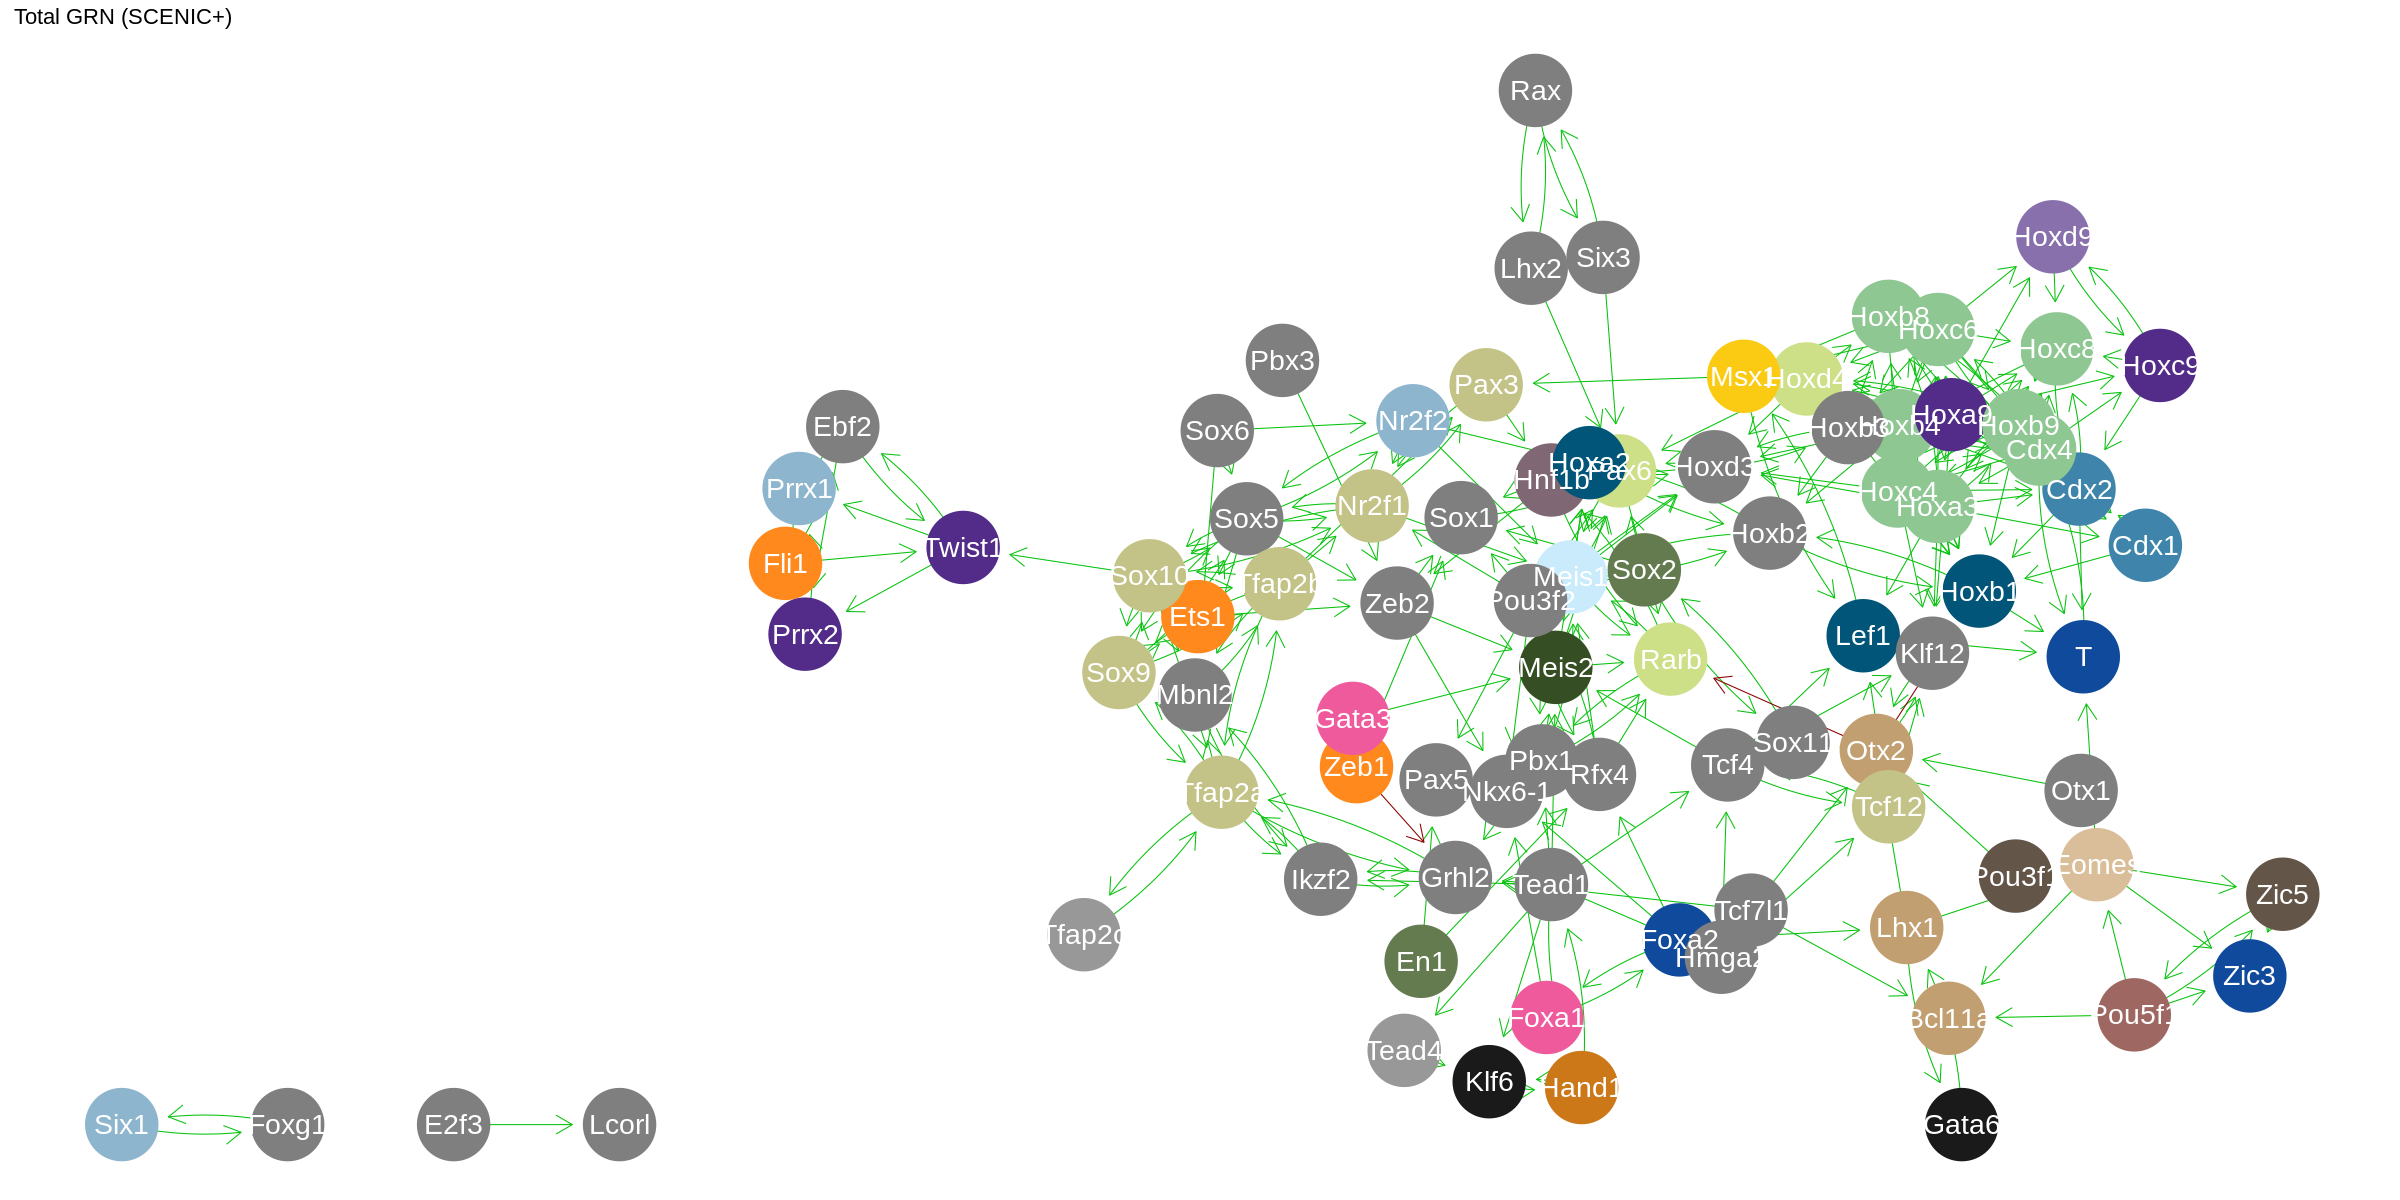

In [171]:
filt = ectoderm %>%
    .[order(-TF2G_importance)] %>% 
    .[TF %in% all_TFs & Gene %in% all_TFs] %>%
    .[R2G_importance> 0.05 & TF2G_importance>10] %>%
    .[,c('TF', 'Gene', 'TF2G_importance', 'TF2G_rho', 'TF2G_importance_x_rho', 'TF2G_regulation')] %>% unique(by=c('TF', 'Gene')) %>%
    .[,sign:=ifelse(TF2G_regulation==-1, 'Negative', 'Positive')]

TF_pass = filt %>% unique(by=c('TF', 'Gene')) %>% .[,N:=.N, by='TF'] %>% .[N>3] %>% .$TF %>% unique()
filt = filt[TF %in% TF_pass & Gene %in% TF_pass]

options(repr.plot.width=20, repr.plot.height=10)
igraph.tbl = tbl_graph(edges = filt) %>%
    mutate(celltype=celltype_marker[names(V(igraph.tbl)),celltype])
ggraph(igraph.tbl, 'stress') +
    # Edges
    geom_edge_fan(aes(edge_color=sign), edge_width=0.3, arrow=arrow(length=unit(4,'mm')), end_cap=circle(10,'mm'), show.legend = T) + 
    scale_edge_colour_manual(values=c("Positive"="#08c20e", "Negative"="darkred")) +
    geom_node_point(aes(col=celltype), size=20) + 
      scale_color_manual(values=c(celltype.colors, 'NA'='#000000')) +  
    geom_node_text(aes(label=name), size=6, col='white') + 
    theme_graph() + 
    ggtitle('Total GRN (SCENIC+)') + theme(legend.position='none')

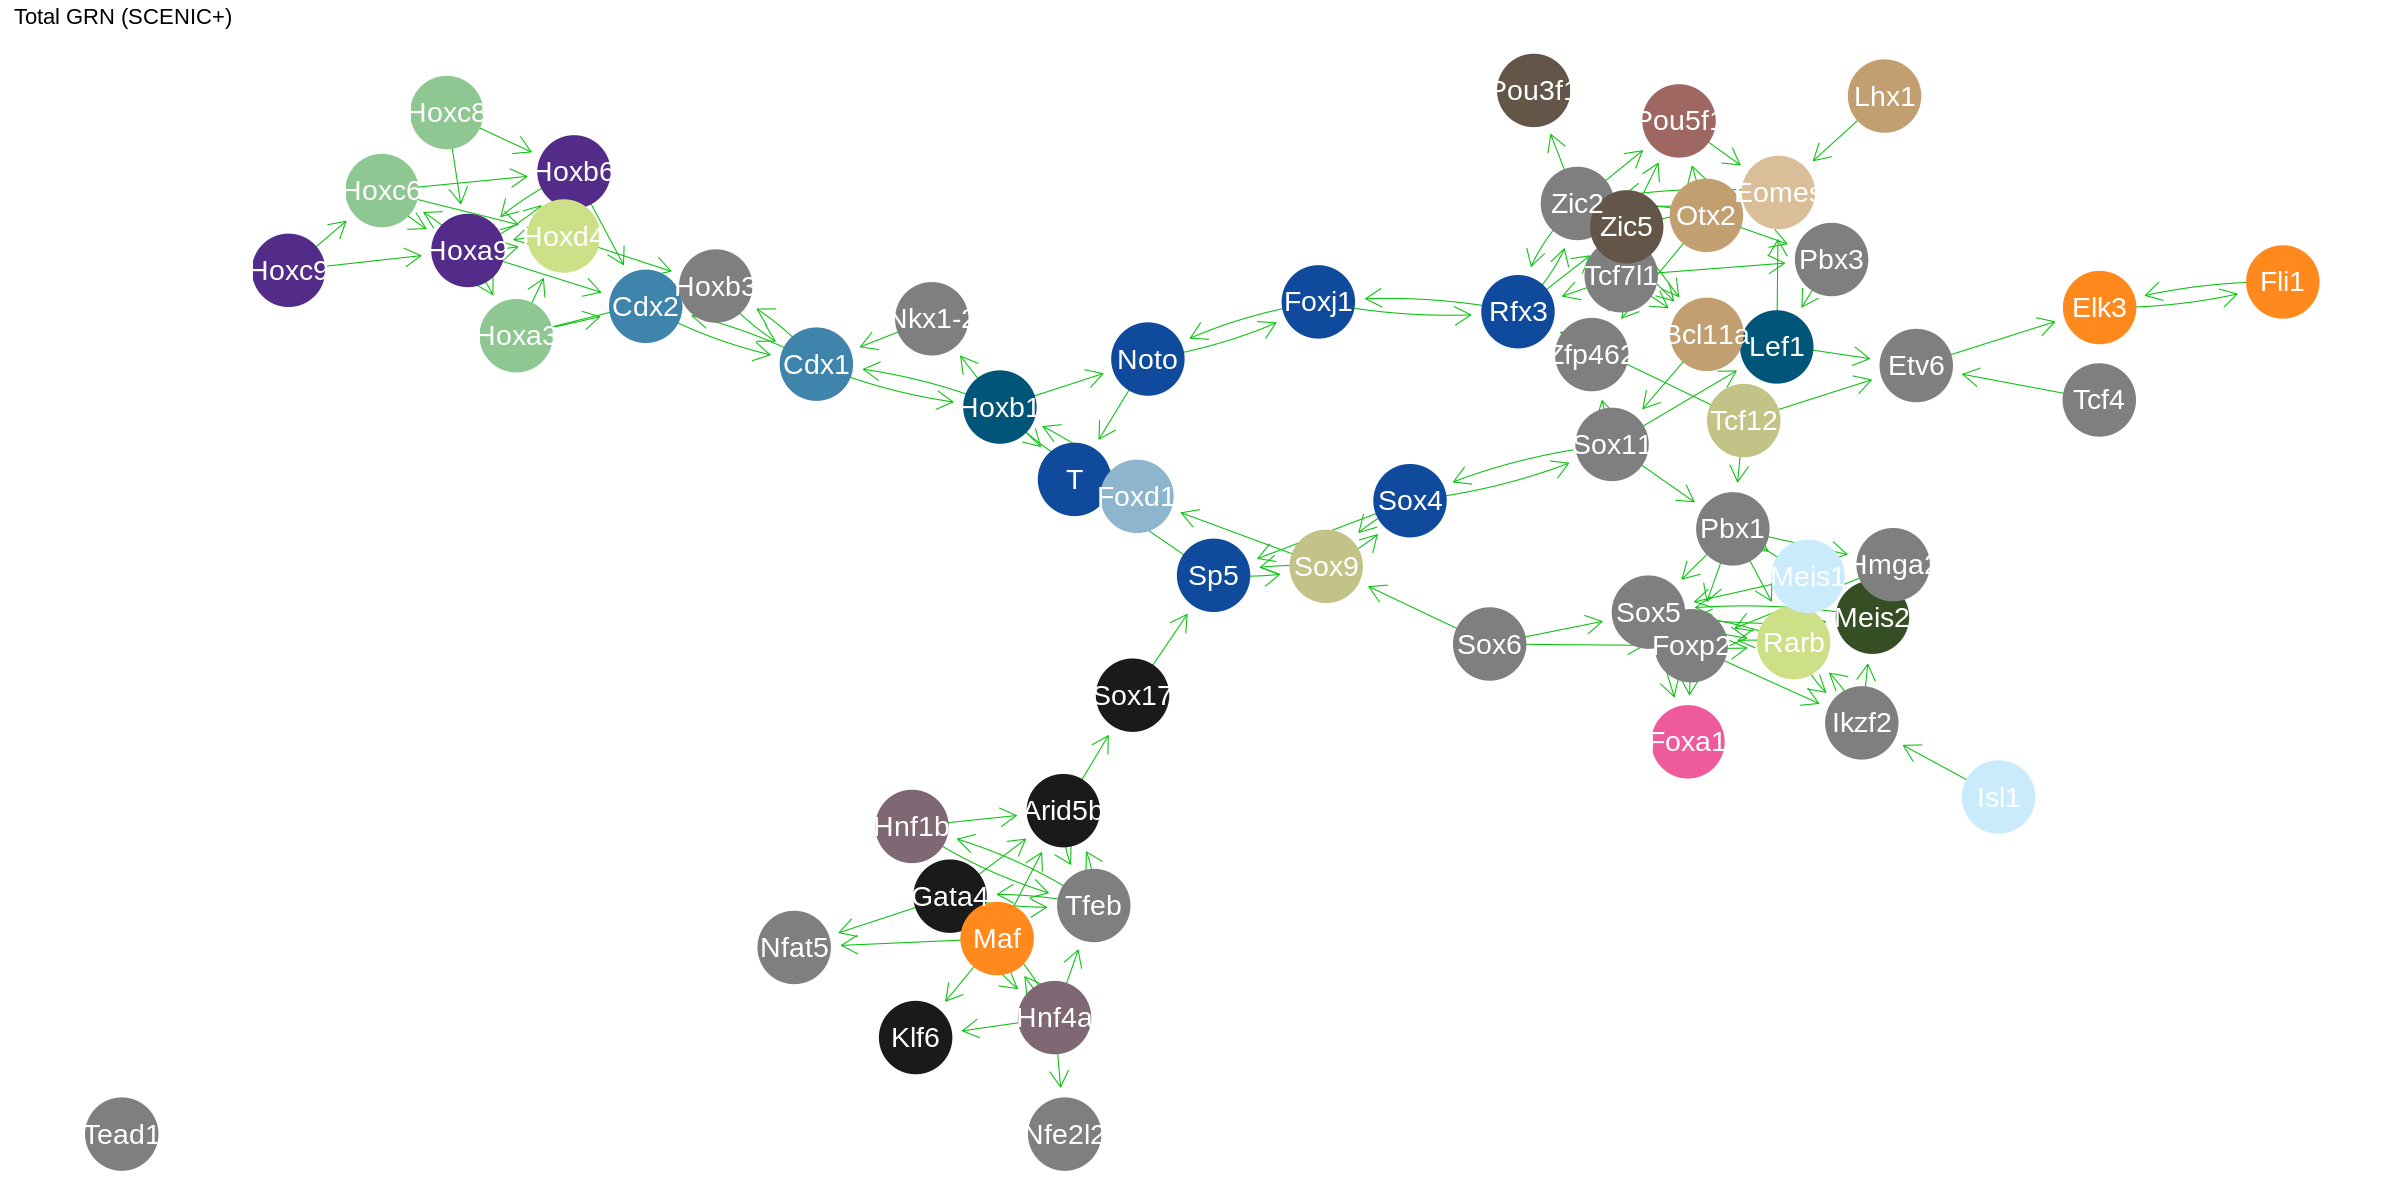

In [181]:
filt = endoderm %>%
    .[order(-TF2G_importance)] %>% 
    .[TF %in% all_TFs & Gene %in% all_TFs] %>%
    .[R2G_importance> 0.05 & TF2G_importance>10] %>%
    .[,c('TF', 'Gene', 'TF2G_importance', 'TF2G_rho', 'TF2G_importance_x_rho', 'TF2G_regulation')] %>% unique(by=c('TF', 'Gene')) %>%
    .[,sign:=ifelse(TF2G_regulation==-1, 'Negative', 'Positive')]

TF_pass = filt %>% unique(by=c('TF', 'Gene')) %>% .[,N:=.N, by='TF'] %>% .[N>3] %>% .$TF %>% unique()
filt = filt[TF %in% TF_pass & Gene %in% TF_pass]

options(repr.plot.width=20, repr.plot.height=10)
igraph.tbl = tbl_graph(edges = filt) %>%
    mutate(celltype=celltype_marker[names(V(igraph.tbl)),celltype])
ggraph(igraph.tbl, 'stress') +
    # Edges
    geom_edge_fan(aes(edge_color=sign), edge_width=0.3, arrow=arrow(length=unit(4,'mm')), end_cap=circle(10,'mm'), show.legend = T) + 
    scale_edge_colour_manual(values=c("Positive"="#08c20e", "Negative"="darkred")) +
    geom_node_point(aes(col=celltype), size=20) + 
      scale_color_manual(values=c(celltype.colors, 'NA'='#000000')) +  
    geom_node_text(aes(label=name), size=6, col='white') + 
    theme_graph() + 
    ggtitle('Total GRN (SCENIC+)') + theme(legend.position='none')